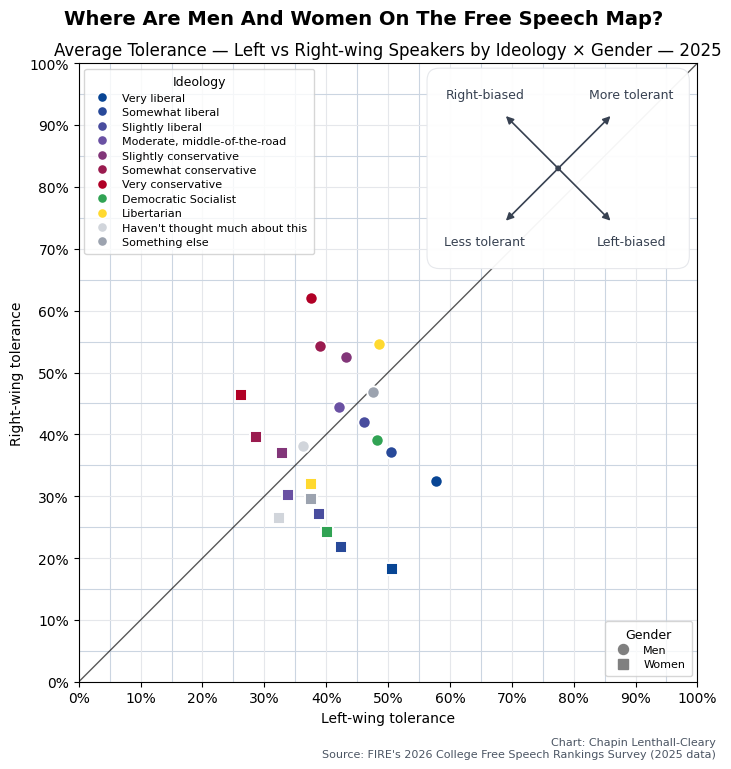

Figure saved to: /Users/chapin.lenthall-cleary/scatter_left_vs_right_avg_by_ideology_gender.png


In [1]:
#!/usr/bin/env python3
"""
Scatter of average tolerance for Left- vs Right-wing speakers (x = Left, y = Right),
with one point per (ideo, gender) group.

• Color = ideology (1..7) on a blue → purple (center) → red gradient
  (1 = Very liberal = blue … 4 = Moderate = purple … 7 = Very conservative = red)
• 8 = Democratic Socialist = green, 9 = Libertarian = yellow
• 10–11 in neutral grays
• Markers = gender (Men/Women)
• Alternating gridlines every 5% (light gray / light-medium gray)

Adds, in the plot’s top-right, a rectangular diagonal compass whose center stays fixed.
We expand the **width only** (horizontal expansion measured in Axes fraction; 0.05 ≈ 5pp).

Compass labels (inside the box):
  ↗ More tolerant
  ↘ Left-biased
  ↖ Right-biased
  ↙ Less tolerant

Saves to:
  scatter_left_vs_right_avg_by_ideology_gender.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle
from pathlib import Path

# --- Config ---
CSV_PATH = Path("cfsrALL.csv")
YEAR = 2025

# --- Compass sizing/position (rectangular; center fixed) ---
# Baseline square box (from earlier version)
BASE_COMPASS_W     = 0.30   # previous width  (axes fraction 0..1)
BASE_COMPASS_H     = 0.30   # previous height (axes fraction 0..1)
BASE_COMPASS_SHIFT = 0.055  # previous left shift (keeps box away from right edge)
H_EXPAND_PP        = 0.1   # expand width by ~5 percentage points of the axes

# Final rectangular size; adjust shift to keep the SAME CENTER horizontally:
# cx = 1 - pad - width/2 - shift_left  → keep cx constant as width changes
COMPASS_W     = BASE_COMPASS_W + H_EXPAND_PP
COMPASS_H     = BASE_COMPASS_H
COMPASS_SHIFT = BASE_COMPASS_SHIFT - (COMPASS_W - BASE_COMPASS_W) / 2.0

IDEO_LABELS = {
    1: "Very liberal",
    2: "Somewhat liberal",
    3: "Slightly liberal",
    4: "Moderate, middle-of-the-road",
    5: "Slightly conservative",
    6: "Somewhat conservative",
    7: "Very conservative",
    8: "Democratic Socialist",
    9: "Libertarian",
    10: "Haven't thought much about this",
    11: "Something else",
}

# Triads
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]  # "Left-wing Speakers"
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD


def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_ideo_like_code(df: pd.DataFrame) -> pd.Series:
    """
    Build ideology 1..11 with preference order:
      • fire_ideo → cp_ideo → ideo
    """
    to_num = lambda c: pd.to_numeric(df.get(c), errors="coerce")
    fire, cp, raw = to_num("fire_ideo"), to_num("cp_ideo"), to_num("ideo")

    valid_fire = (fire >= 1) & (fire <= 11)
    valid_cp   = (cp   >= 1) & (cp   <= 11)
    valid_raw  = (raw  >= 1) & (raw  <= 11)

    ideo = np.where(valid_fire, fire,
             np.where(valid_cp, cp,
             np.where(valid_raw, raw, np.nan)))
    return pd.Series(ideo, index=df.index).astype("Int64")


def add_diagonal_compass(ax, *, width, height, pad=0.02, shift_left):
    """
    Draw a diagonal compass INSIDE the axes using a rectangular box.
    `width` and `height` are in Axes fraction units (0..1).
    Center remains fixed based on (width, height, shift_left, pad).

    Labels (inside the box):
      ↗ More tolerant
      ↘ Left-biased
      ↖ Right-biased
      ↙ Less tolerant
    """
    # Fixed center location with given width/height
    cx = 1 - pad - width / 2 - shift_left
    cy = 1 - pad - height / 2

    # Background box
    box = FancyBboxPatch(
        (cx - width/2, cy - height/2), width, height,
        transform=ax.transAxes, boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=0.8, facecolor="white", edgecolor="#e5e7eb", alpha=0.95, zorder=5
    )
    ax.add_patch(box)

    # Margins and geometry for arrows/labels
    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.05  # proportional inner margin

    def r_max(theta):
        """Max radius from center to stay inside rectangle minus margin."""
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9); st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    color = "#374151"
    lw = 1.2
    ms = 11
    fz = 9.0

    directions = [
        ( 45, "More tolerant"),  # NE
        (-45, "Left-biased"),    # SE
        (135, "Right-biased"),   # NW
        (225, "Less tolerant"),  # SW
    ]

    for angle_deg, label in directions:
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.65
        r_label = rmax * 0.88

        x_tip = cx + r_arrow * np.cos(th)
        y_tip = cy + r_arrow * np.sin(th)
        ax.add_patch(FancyArrowPatch(
            (cx, cy), (x_tip, y_tip),
            transform=ax.transAxes, arrowstyle="-|>", mutation_scale=ms,
            linewidth=lw, color=color, zorder=6
        ))

        ax.text(
            cx + r_label * np.cos(th),
            cy + r_label * np.sin(th),
            label, transform=ax.transAxes,
            ha="center", va="center", fontsize=fz, color=color, zorder=7
        )

    ax.add_patch(Circle((cx, cy), radius=min(width, height) * 0.012,
                        transform=ax.transAxes, color=color, zorder=7))


def make_ideo_gender_scatter(df: pd.DataFrame, year: int):
    """
    df: already filtered to year, gender=={1,2}, ideo in 1..11, all six spk_* in [1,4]
    """
    df = df.copy()

    # Triad sums & scale to percent (0..100)
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"]  = df[LEFT_TRIAD].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"]  = scale_triad_to_pct(df["left_sum"],  k=len(LEFT_TRIAD))

    # Group means and sizes
    stats = (df.groupby(["ideo", "gender_bin"], dropna=True)
               .agg(left_avg=("left_pct", "mean"),
                    right_avg=("right_pct", "mean"),
                    n=("left_pct", "size"))
               .reset_index())
    if stats.empty:
        raise SystemExit("No groups to plot after filtering—check data/filtering.")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8.8, 8.6))

    # Blue → Purple (center) → Red; center aligns at ideo=4 when sampling 7 steps
    cmap_lr = LinearSegmentedColormap.from_list(
        "blue_purple_red",
        ["#084594", "#6a51a3", "#b10026"]  # deep blue, purple midpoint, deep red
    )
    steps7 = np.linspace(0, 1, 7)
    ideology_colors = {i: cmap_lr(steps7[i - 1]) for i in range(1, 8)}
    ideology_colors.update({
        8: "#31a354",   # Democratic Socialist = green
        9: "#ffd92f",   # Libertarian = yellow
        10: "#d1d5db",  # Haven't thought much = light gray
        11: "#9ca3af",  # Something else = medium gray
    })

    # Markers for gender
    gender_markers = {1: "o", 2: "s"}  # Men = circle, Women = square

    # Alternating 5% gridlines (light / light-medium gray)
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)

    # Plot each point
    for _, row in stats.iterrows():
        i, g = int(row["ideo"]), int(row["gender_bin"])
        ax.scatter(
            row["left_avg"], row["right_avg"],
            s=80,
            c=[ideology_colors.get(i, "#9ca3af")],
            marker=gender_markers.get(g, "o"),
            edgecolor="white",
            linewidth=1.4,
            zorder=3
        )

    # Axes, labels, formatting
    ax.set_title(f"Average Tolerance — Left vs Right-wing Speakers by Ideology × Gender — {year}")
    ax.set_xlabel("Left-wing tolerance")
    ax.set_ylabel("Right-wing tolerance")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(range(0, 101, 10)); ax.set_yticks(range(0, 101, 10))

    # Diagonal parity line
    ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    # >>> Rectangular compass — horizontally expanded only; center fixed <<<
    add_diagonal_compass(ax, width=COMPASS_W, height=COMPASS_H, pad=0.02, shift_left=COMPASS_SHIFT)

    # Legends — make both just a hair smaller
    ideo_handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=ideology_colors[i], markeredgecolor="white", markersize=8,
               label=IDEO_LABELS[i])
        for i in range(1, 12)
    ]
    gender_handles = [
        Line2D([0], [0], marker=gender_markers[1], linestyle="", color="gray", label="Men", markersize=8),
        Line2D([0], [0], marker=gender_markers[2], linestyle="", color="gray", label="Women", markersize=8),
    ]

    leg1 = ax.legend(
        handles=ideo_handles, title="Ideology", loc="upper left", frameon=True,
        fontsize=8, title_fontsize=9, markerscale=0.9, borderpad=0.6, labelspacing=0.4
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=gender_handles, title="Gender", loc="lower right", frameon=True,
        fontsize=8, title_fontsize=9, markerscale=0.9, borderpad=0.6, labelspacing=0.4
    )

    # New headline above the existing title (closer to the plot)
    fig.suptitle(
        "Where Are Men And Women On The Free Speech Map?",
        fontsize=14, fontweight="bold", y=0.9
    )

    # Credits in the bottom-right corner (pulled up closer to the plot)
    fig.text(
        0.9, 0.028,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )

    # Leave room for the titles/credits while keeping axes size effectively unchanged
    fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])

    out_path = Path("scatter_left_vs_right_avg_by_ideology_gender.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")


def main():
    # Load
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Coerce relevant columns to numeric
    for col in ["datayear", "gender_bin", *SPK_ALL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Build ideology
    df["ideo"] = build_ideo_like_code(df)

    # Filter to target year, men/women only, and ideology 1..11
    df = df[(df["datayear"] == YEAR) & (df["gender_bin"].isin([1, 2])) & (df["ideo"].isin(range(1, 12)))]
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {YEAR}, genders in [1,2], and ideo in 1..11.")

    # Require ALL six spk_* in [1,4]
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* to be in [1,4].")

    make_ideo_gender_scatter(df, YEAR)


if __name__ == "__main__":
    main()


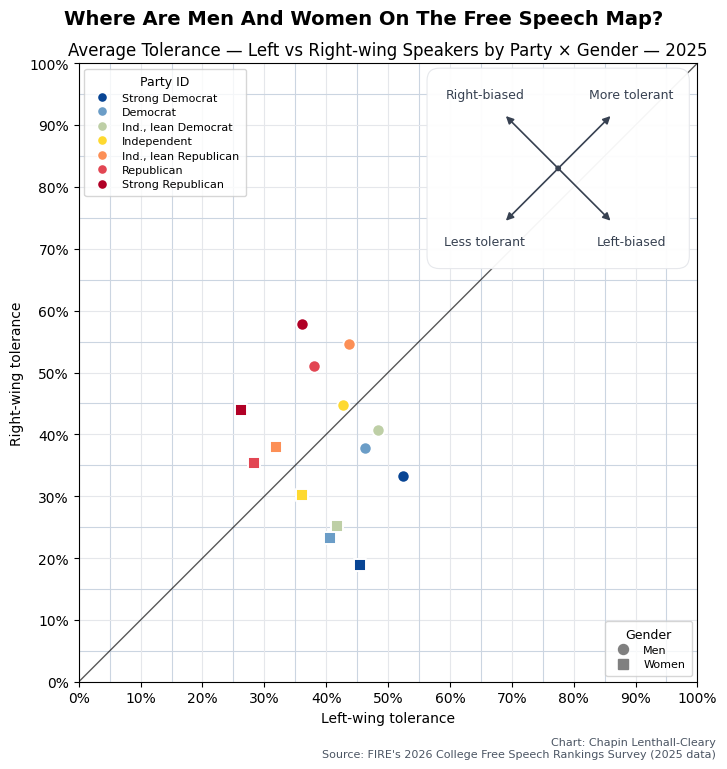

Figure saved to: /Users/chapin.lenthall-cleary/scatter_left_vs_right_avg_by_party_gender.png


In [2]:
#!/usr/bin/env python3
"""
Scatter of average tolerance for Left- vs Right-wing speakers (x = Left, y = Right),
with one point per (partyid, gender) group.

• Color = partyid (1..7) on a discrete 7-step gradient:
  red → light red → yellow → light blue → blue
  (1 = Strong Dem = blue … 7 = Strong Rep = red)
• Markers = gender (Men/Women)
• Axes are 0–100% and include the diagonal parity line (Left == Right)
• Alternating gridlines every 5% (light gray / light-medium gray)

Saves to:
  scatter_left_vs_right_avg_by_party_gender.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle  # NEW
from pathlib import Path

# --- Config ---
CSV_PATH = Path("cfsrALL.csv")
YEAR = 2025
GENDER_LABELS = {1: "Men", 2: "Women"}

# partyid guide 1..7 (removed the word "Weak")
PARTY_LABELS_FULL = {
    1: "Strong Democrat",
    2: "Democrat",
    3: "Ind., lean Democrat",
    4: "Independent",
    5: "Ind., lean Republican",
    6: "Republican",
    7: "Strong Republican",
}

# Triads (same as your original)
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]  # "Left-wing Speakers"
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD

# --- Compass sizing/position (rectangular; center fixed) ---  # NEW
BASE_COMPASS_W     = 0.30   # previous width  (axes fraction 0..1)
BASE_COMPASS_H     = 0.30   # previous height (axes fraction 0..1)
BASE_COMPASS_SHIFT = 0.055  # previous left shift (keeps box away from right edge)
H_EXPAND_PP        = 0.10   # expand width by ~10 percentage points of the axes

COMPASS_W     = BASE_COMPASS_W + H_EXPAND_PP
COMPASS_H     = BASE_COMPASS_H
COMPASS_SHIFT = BASE_COMPASS_SHIFT - (COMPASS_W - BASE_COMPASS_W) / 2.0

def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_partyid_like_code2(df: pd.DataFrame) -> pd.Series:
    """
    Recreates the partyid logic from code 2:
      Prefer 1–7 from fire_partyid, else 1–7 from cp_partyid.
      If neither is 1–7 but either is 8, set to 8; else NaN.
    Returns a nullable Int64 series.
    """
    fire = pd.to_numeric(df.get("fire_partyid"), errors="coerce")
    cp   = pd.to_numeric(df.get("cp_partyid"),   errors="coerce")

    valid_fire_1_7 = (fire >= 1) & (fire <= 7)
    valid_cp_1_7   = (cp   >= 1) & (cp   <= 7)

    partyid = np.where(valid_fire_1_7, fire,
               np.where(valid_cp_1_7,   cp,   np.nan))
    partyid = np.where(pd.isna(partyid) & ((fire == 8) | (cp == 8)), 8, partyid)
    return pd.Series(partyid, index=df.index).astype("Int64")


# NEW: Diagonal compass (same look/behavior as Code 2)
def add_diagonal_compass(ax, *, width, height, pad=0.02, shift_left):
    """
    Draw a diagonal compass INSIDE the axes using a rectangular box.
    `width` and `height` are in Axes fraction units (0..1).
    Center remains fixed based on (width, height, shift_left, pad).

    Labels (inside the box):
      ↗ More tolerant
      ↘ Left-biased
      ↖ Right-biased
      ↙ Less tolerant
    """
    # Fixed center location with given width/height
    cx = 1 - pad - width / 2 - shift_left
    cy = 1 - pad - height / 2

    # Background box
    box = FancyBboxPatch(
        (cx - width/2, cy - height/2), width, height,
        transform=ax.transAxes, boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=0.8, facecolor="white", edgecolor="#e5e7eb", alpha=0.95, zorder=5
    )
    ax.add_patch(box)

    # Margins and geometry for arrows/labels
    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.05  # proportional inner margin

    def r_max(theta):
        """Max radius from center to stay inside rectangle minus margin."""
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9); st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    color = "#374151"
    lw = 1.2
    ms = 11
    fz = 9.0

    directions = [
        ( 45, "More tolerant"),  # NE
        (-45, "Left-biased"),    # SE
        (135, "Right-biased"),   # NW
        (225, "Less tolerant"),  # SW
    ]

    for angle_deg, label in directions:
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.65
        r_label = rmax * 0.88

        x_tip = cx + r_arrow * np.cos(th)
        y_tip = cy + r_arrow * np.sin(th)
        ax.add_patch(FancyArrowPatch(
            (cx, cy), (x_tip, y_tip),
            transform=ax.transAxes, arrowstyle="-|>", mutation_scale=ms,
            linewidth=lw, color=color, zorder=6
        ))

        ax.text(
            cx + r_label * np.cos(th),
            cy + r_label * np.sin(th),
            label, transform=ax.transAxes,
            ha="center", va="center", fontsize=fz, color=color, zorder=7
        )

    ax.add_patch(Circle((cx, cy), radius=min(width, height) * 0.012,
                        transform=ax.transAxes, color=color, zorder=7))


def make_party_gender_scatter(df: pd.DataFrame, year: int):
    """
    df: already filtered to year, gender=={1,2}, partyid in 1..7, all six spk_* in [1,4]
    Produces a single scatter plot of group averages with:
      • color = partyid (1..7) on specified red→…→blue gradient
      • marker = gender (Men/Women)
    """
    df = df.copy()

    # Triad sums & scale to percent (0..100)
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"]  = df[LEFT_TRIAD].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"]  = scale_triad_to_pct(df["left_sum"],  k=len(LEFT_TRIAD))

    # Group means and sizes
    grp = df.groupby(["partyid", "gender_bin"], dropna=True)
    stats = grp.agg(
        left_avg=("left_pct", "mean"),
        right_avg=("right_pct", "mean"),
        n=("left_pct", "size")
    ).reset_index()

    if stats.empty:
        raise SystemExit("No groups to plot after filtering—check data/filtering.")

    # --- Plot (match plot 2 size) ---
    fig, ax = plt.subplots(figsize=(8.8, 8.6))

    # Build continuous colormap with specified stops, then sample 7 discrete colors
    cmap_cont = LinearSegmentedColormap.from_list(
        "red_lightred_yellow_lightblue_blue",
        ["#b10026", "#fb6a6a", "#ffd92f", "#9ecae1", "#084594"]
    )

    # Map partyid 1..7 to 7 evenly spaced samples but reversed
    steps = np.linspace(0, 1, 7)
    party_colors = {pid: cmap_cont(steps[7 - pid]) for pid in range(1, 8)}

    # Markers for gender
    gender_markers = {1: "o", 2: "s"}  # Men = circle, Women = square

    # Alternating 5% gridlines (light / light-medium gray)
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)

    # Plot each point
    for _, row in stats.iterrows():
        pid = int(row["partyid"])
        g   = int(row["gender_bin"])
        ax.scatter(
            row["left_avg"], row["right_avg"],
            s=80,
            c=[party_colors.get(pid)],
            marker=gender_markers.get(g, "o"),
            edgecolor="white",
            linewidth=1.4,
            zorder=3
        )

    # Axes, labels, formatting
    ax.set_title(f"Average Tolerance — Left vs Right-wing Speakers by Party × Gender — {year}")
    ax.set_xlabel("Left-wing tolerance")
    ax.set_ylabel("Right-wing tolerance")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(range(0, 101, 10)); ax.set_yticks(range(0, 101, 10))

    # Diagonal parity line
    ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    # Legends — match plot 2 styling
    party_handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=party_colors[pid], markeredgecolor="white", markersize=8,
               label=PARTY_LABELS_FULL[pid])
        for pid in range(1, 8)
    ]
    gender_handles = [
        Line2D([0], [0], marker=gender_markers[1], linestyle="", color="gray", label="Men", markersize=8),
        Line2D([0], [0], marker=gender_markers[2], linestyle="", color="gray", label="Women", markersize=8),
    ]

    leg1 = ax.legend(
        handles=party_handles, title="Party ID", loc="upper left", frameon=True,
        fontsize=8, title_fontsize=9, markerscale=0.9, borderpad=0.6, labelspacing=0.4
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=gender_handles, title="Gender", loc="lower right", frameon=True,
        fontsize=8, title_fontsize=9, markerscale=0.9, borderpad=0.6, labelspacing=0.4
    )

    # Rectangular compass — horizontally expanded only; center fixed
    add_diagonal_compass(ax, width=COMPASS_W, height=COMPASS_H, pad=0.02, shift_left=COMPASS_SHIFT)

    # Big headline and lower-right credits (already added in your file)
    fig.suptitle(
        "Where Are Men And Women On The Free Speech Map?",
        fontsize=14, fontweight="bold", y=0.9
    )
    fig.text(
        0.9, 0.028,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )

    # Leave room for suptitle/credits while keeping axes size effectively unchanged
    fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])

    out_path = Path("scatter_left_vs_right_avg_by_party_gender.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")



def main():
    # Load
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Coerce relevant columns to numeric
    numeric_cols = ["datayear", "gender_bin", *SPK_ALL]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Build partyid as in code 2
    df["partyid"] = build_partyid_like_code2(df)

    # Filter to target year, men/women only, and partyid 1..7
    df = df[(df["datayear"] == YEAR) & (df["gender_bin"].isin([1, 2])) & (df["partyid"].isin(range(1, 8)))]
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {YEAR}, genders in [1,2], and partyid in 1..7.")

    # Require ALL six spk_* in [1,4], matching earlier scripts
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* to be in [1,4].")

    # Make the scatter
    make_party_gender_scatter(df, YEAR)


if __name__ == "__main__":
    main()


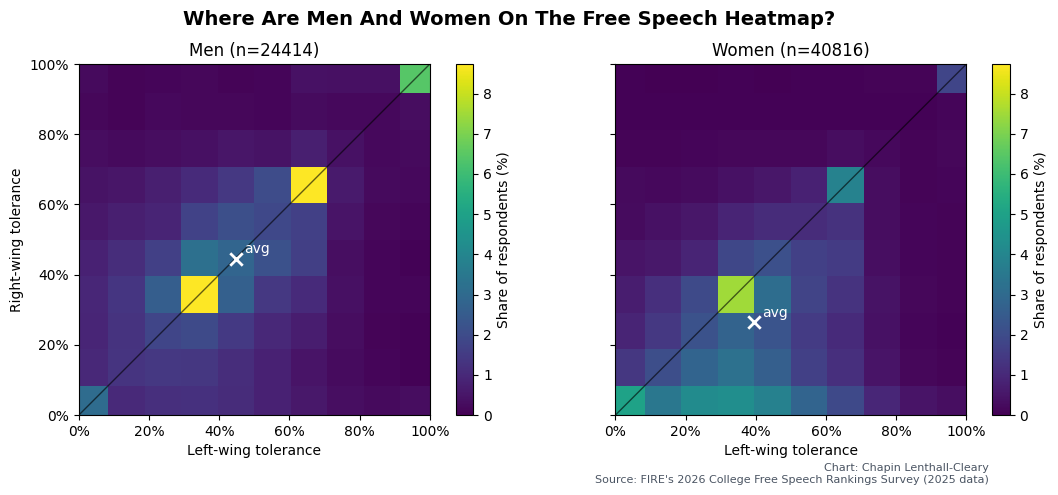

Figure saved to: /Users/chapin.lenthall-cleary/heatmap_left_vs_right_by_gender.png


In [3]:
#!/usr/bin/env python3
"""
Heatmaps of tolerance for Left- vs Right-wing speakers (x = Left, y = Right),
shown separately for Men and Women. Values are scaled to 0–100% using the same
mapping as your triad plots (sum k..4k -> 0..100 where k=len(triad)=3).

Outputs one figure with two panels and saves it to:
  heatmap_left_vs_right_by_gender.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

# --- Config ---
CSV_PATH = Path("cfsrALL.csv")
YEAR = 2025
GENDER_LABELS = {1: "Men", 2: "Women"}

# Keep your original triads/naming
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]          # "Right-wing Speakers" per your scripts
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]  # "Left-wing Speakers"
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD


def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def make_joint_heatmaps(df, year):
    """
    df: already filtered to year, gender=={1,2}, all six spk_* in [1,4]
    Creates a 1x2 figure: Men | Women heatmaps of Left (x) vs Right (y) tolerance.
    """
    # Compute triad sums & scale to percent (0..100)
    df = df.copy()
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"]  = df[LEFT_TRIAD].sum(axis=1).astype(int)

    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"]  = scale_triad_to_pct(df["left_sum"],  k=len(LEFT_TRIAD))

    # Binning edges: 0..100 with a small buffer so edge values show
    edges = np.linspace(-2, 102, 11)  # ~10% bins with a touch of breathing room

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)  # (unchanged size)
    cmax = 0.0  # track global max % for consistent color scaling

    # First pass: compute normalized grids to get a common vmax (percent)
    grids = {}
    for g, ax in zip([1, 2], axes):
        sub = df[df["gender_bin"] == g]
        if sub.empty:
            grids[g] = (np.zeros((len(edges)-1, len(edges)-1)), None, None, 0)
            continue

        # NOTE: x = Left, y = Right
        H, xedges, yedges = np.histogram2d(
            sub["left_pct"], sub["right_pct"],
            bins=[edges, edges]
        )
        pct = (H / len(sub)) * 100.0  # percent of respondents in each bin
        grids[g] = (pct, xedges, yedges, len(sub))
        cmax = max(cmax, pct.max())

    # Second pass: plot with a common vmax so colors are comparable
    for g, ax in zip([1, 2], axes):
        pct, xedges, yedges, n = grids[g]

        mesh = ax.pcolormesh(
            xedges, yedges, pct.T,
            shading="auto",
            vmin=0, vmax=max(1e-9, cmax)
        )
        cb = fig.colorbar(mesh, ax=ax)
        cb.set_label("Share of respondents (%)")

        # Axes formatting
        ax.set_title(f"{GENDER_LABELS[g]} (n={n})")
        ax.set_xlabel("Left-wing tolerance")
        if g == 1:
            ax.set_ylabel("Right-wing tolerance")

        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.set_aspect("equal", adjustable="box")

        # Diagonal parity line
        ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.6)

        # Group means (x=Left, y=Right)
        sub = df[df["gender_bin"] == g]
        if not sub.empty:
            mx = sub["left_pct"].mean()
            my = sub["right_pct"].mean()
            ax.scatter([mx], [my], marker="x", s=80, color="white", linewidths=2, zorder=3)
            ax.annotate("avg", (mx, my), textcoords="offset points", xytext=(6, 4), color="white")

    # --- NEW: Bold headline (same as plot 2) ---
    fig.suptitle(
        "Where Are Men And Women On The Free Speech Heatmap?",
        fontsize=14, fontweight="bold", y=0.93
    )

    # --- NEW: Lower-right credits (same as plot 2) ---
    fig.text(
        .9, -0.02,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )

    # Leave space for the headline/credits without changing figsize
    fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])

    out_path = Path("heatmap_left_vs_right_by_gender.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")



def main():
    # Load
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Coerce relevant columns to numeric
    numeric_cols = ["datayear", "gender_bin", "mh_stressed", *SPK_ALL]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Filter to target year and men/women only
    df = df[(df["datayear"] == YEAR) & (df["gender_bin"].isin([1, 2]))]
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {YEAR} and gender_bin in [1,2].")

    # Require ALL six spk_* in [1,4], matching your earlier scripts
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* to be in [1,4].")

    # Make the heatmaps
    make_joint_heatmaps(df, YEAR)


if __name__ == "__main__":
    main()


/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_79011/1665490803.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])


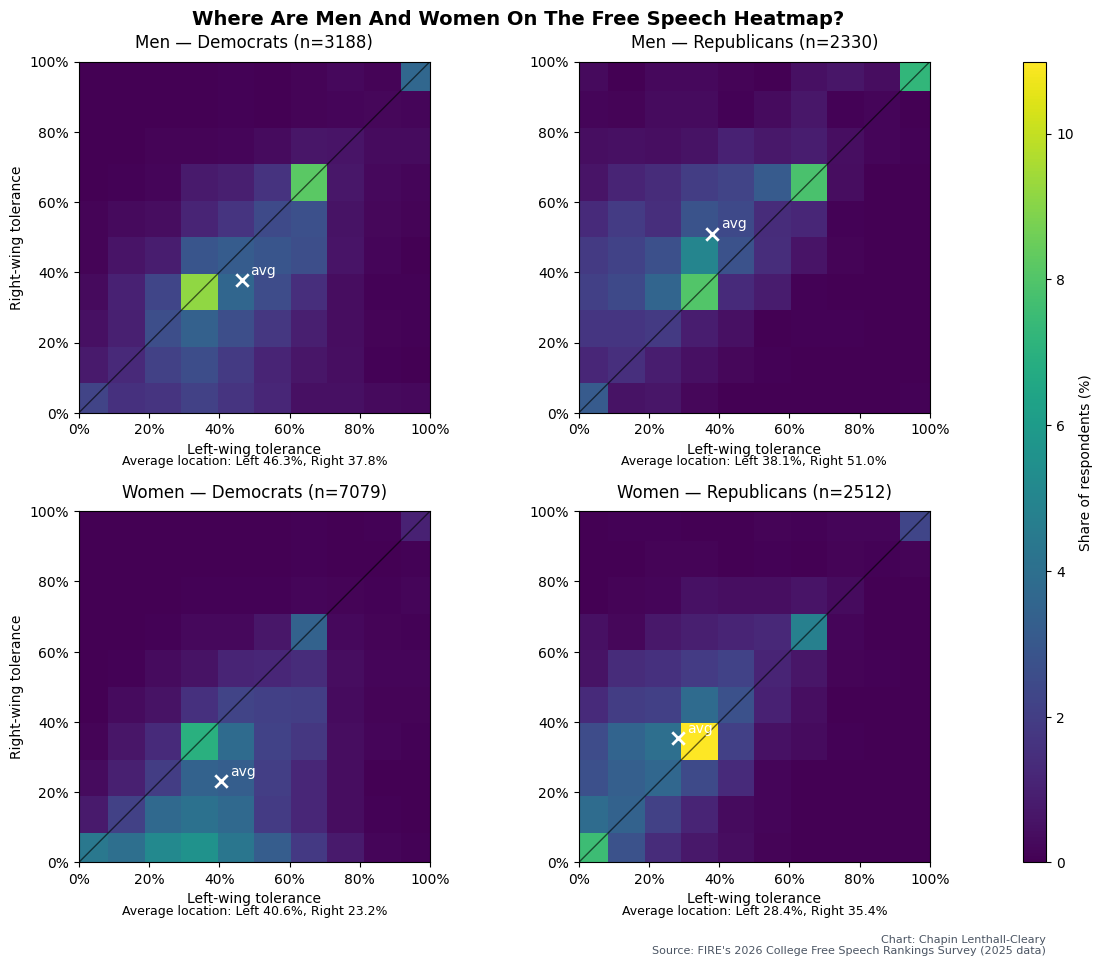

Figure saved to: /Users/chapin.lenthall-cleary/heatmap_left_vs_right_by_gender_party_regular.png


In [4]:
#!/usr/bin/env python3
"""
Heatmaps of tolerance for Left- vs Right-wing speakers (x = Left, y = Right),
split into four groups:
  • Men — Democrats
  • Men — Republicans
  • Women — Democrats
  • Women — Republicans

Values are scaled to 0–100% using the same mapping as your triad plots
(sum k..4k -> 0..100 where k=len(triad)=3).

Outputs one figure with four panels and saves it to:
  heatmap_left_vs_right_by_gender_party_regular.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

# --- Config ---
CSV_PATH = Path("cfsrALL.csv")
YEAR = 2025
GENDER_LABELS = {1: "Men", 2: "Women"}
# Use regular party categories (Democrats=2, Republicans=6)
PARTY_LABELS = {2: "Democrats", 6: "Republicans"}

# Triads (keep your original naming)
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]  # "Left-wing Speakers"
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD


def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_partyid_like_code2(df: pd.DataFrame) -> pd.Series:
    """
    Recreates the partyid logic from code 2:
      Prefer 1–7 from fire_partyid, else 1–7 from cp_partyid.
      If neither is 1–7 but either is 8, set to 8; else NaN.
    Returns a nullable Int64 series.
    """
    fire = pd.to_numeric(df.get("fire_partyid"), errors="coerce")
    cp   = pd.to_numeric(df.get("cp_partyid"),   errors="coerce")

    valid_fire_1_7 = (fire >= 1) & (fire <= 7)
    valid_cp_1_7   = (cp   >= 1) & (cp   <= 7)

    partyid = np.where(valid_fire_1_7, fire,
               np.where(valid_cp_1_7,   cp,   np.nan))
    partyid = np.where(pd.isna(partyid) & ((fire == 8) | (cp == 8)), 8, partyid)
    return pd.Series(partyid, index=df.index).astype("Int64")


def make_quad_heatmaps(df, year):
    """
    df: already filtered to year, gender=={1,2}, partyid in {2,6}, all six spk_* in [1,4]
    Creates a 2x2 figure with a dedicated colorbar axis on the far right and
    a line of text below each plot describing the average location.
    """
    df = df.copy()
    # Triad sums & scale to percent (0..100)
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"]  = df[LEFT_TRIAD].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"]  = scale_triad_to_pct(df["left_sum"],  k=len(LEFT_TRIAD))

    # Binning edges: ~10% bins with small buffers so edge values show
    edges = np.linspace(-2, 102, 11)

    # --- Figure layout: 2x3 grid, last column reserved for colorbar ---
    fig = plt.figure(figsize=(13.2, 10.4))
    gs = fig.add_gridspec(
        nrows=2, ncols=3,
        width_ratios=[1, 1, 0.05],
        wspace=0.12, hspace=0.28   # extra vertical space between rows
    )
    axes = [
        fig.add_subplot(gs[0, 0]),  # Men — Democrats
        fig.add_subplot(gs[0, 1]),  # Men — Republicans
        fig.add_subplot(gs[1, 0]),  # Women — Democrats
        fig.add_subplot(gs[1, 1]),  # Women — Republicans
    ]
    cax = fig.add_subplot(gs[:, 2])  # dedicated colorbar axis spanning both rows

    # Order ensures left column is Democrats (party 2), right column Republicans (party 6)
    groups = [(1, 2), (1, 6), (2, 2), (2, 6)]

    # First pass: build grids and global vmax so colors are comparable
    cmax = 0.0
    grids = {}
    for (g, p) in groups:
        sub = df[(df["gender_bin"] == g) & (df["partyid"] == p)]
        if sub.empty:
            grids[(g, p)] = (np.zeros((len(edges)-1, len(edges)-1)), edges, edges, 0, np.nan, np.nan)
            continue
        # NOTE: x = Left, y = Right
        H, xedges, yedges = np.histogram2d(sub["left_pct"], sub["right_pct"], bins=[edges, edges])
        pct = (H / len(sub)) * 100.0
        mx = sub["left_pct"].mean()
        my = sub["right_pct"].mean()
        grids[(g, p)] = (pct, xedges, yedges, len(sub), mx, my)
        cmax = max(cmax, pct.max())

    meshes = []
    for ax, (g, p) in zip(axes, groups):
        pct, xedges, yedges, n, mx, my = grids[(g, p)]
        mesh = ax.pcolormesh(
            xedges, yedges, pct.T,
            shading="auto", vmin=0, vmax=max(1e-9, cmax)
        )
        meshes.append(mesh)

        # Titles & labels
        title_txt = f"{GENDER_LABELS[g]} — {PARTY_LABELS[p]} (n={n})"
        ax.set_title(title_txt, pad=10)

        ax.set_xlabel("Left-wing tolerance")
        if p == 2:  # left column (Democrats)
            ax.set_ylabel("Right-wing tolerance")

        # 0..100% axes with percent tick formatting
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.set_aspect("equal", adjustable="box")

        # Diagonal parity line (Left == Right)
        ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.6)

        # Group mean marker + label and text below plot
        if n > 0 and not (np.isnan(mx) or np.isnan(my)):
            ax.scatter([mx], [my], marker="x", s=80, color="white", linewidths=2, zorder=3)
            ax.annotate("avg", (mx, my), textcoords="offset points", xytext=(6, 4), color="white")
            avg_text = f"Average location: Left {mx:.1f}%, Right {my:.1f}%"
        else:
            avg_text = "Average location: —"

        # Place the average text *close below* each plot (axes-relative coordinates)
        ax.text(
            0.5, -0.12, avg_text,   # adjust this value to move closer/farther
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9
        )

    # Dedicated colorbar (won't overlap plots)
    cbar = fig.colorbar(meshes[0], cax=cax)
    cbar.set_label("Share of respondents (%)")

    # --- NEW: Bold headline (to match Code 2 style) ---
    fig.suptitle(
        "Where Are Men And Women On The Free Speech Heatmap?",
        fontsize=14, fontweight="bold", y=0.93
    )

    # --- NEW: Lower-right credits (to match Code 2 style) ---
    fig.text(
        0.90, .02,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )

    # Leave room for suptitle & credits without changing figsize
    fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])

    out_path = Path("heatmap_left_vs_right_by_gender_party_regular.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")


def main():
    # Load
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Coerce relevant columns to numeric
    numeric_cols = ["datayear", "gender_bin", *SPK_ALL]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Build partyid as in code 2
    df["partyid"] = build_partyid_like_code2(df)

    # Filter to target year, men/women only, and partyid Democrats (2) or Republicans (6)
    df = df[(df["datayear"] == YEAR) & (df["gender_bin"].isin([1, 2])) & (df["partyid"].isin([2, 6]))]
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {YEAR}, genders in [1,2], and partyid in [2,6].")

    # Require ALL six spk_* in [1,4], matching earlier scripts
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* to be in [1,4].")

    # Make the 2x2 heatmaps
    make_quad_heatmaps(df, YEAR)


if __name__ == "__main__":
    main()
